In [3]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model
import os
from pathlib import Path
import random
from sklearn.utils import resample

In [5]:
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
class GTSRBDataAugmenter:
    def __init__(self, target_size=(32, 32)):
        self.target_size = target_size
    #randomly apply augmentation technique  
    def augment_image(self, image):
        aug_type = random.choice(['rotate', 'zoom', 'brightness', 'contrast', 
                                'translation', 'gaussian_noise', 'blur'])
        
        if aug_type == 'rotate':
            angle = random.uniform(-15, 15)
            matrix = cv2.getRotationMatrix2D((16, 16), angle, 1.0)
            return cv2.warpAffine(image, matrix, self.target_size, borderMode=cv2.BORDER_REFLECT)
            
        elif aug_type == 'zoom':
            zoom_factor = random.uniform(0.8, 1.2)
            new_size = int(32 * zoom_factor)
            resized = cv2.resize(image, (new_size, new_size))
            if zoom_factor > 1:
                start = (new_size - 32) // 2
                return resized[start:start+32, start:start+32]
            else:
                pad = (32 - new_size) // 2
                return cv2.copyMakeBorder(resized, pad, pad, pad, pad, cv2.BORDER_REFLECT)
                
        elif aug_type == 'brightness':
            hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
            hsv = hsv.astype(np.float32)
            hsv[:,:,2] *= random.uniform(0.7, 1.3)
            hsv[:,:,2] = np.clip(hsv[:,:,2], 0, 255)
            hsv = hsv.astype(np.uint8)
            return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
            
        elif aug_type == 'contrast':
            alpha = random.uniform(0.8, 1.2)
            return cv2.convertScaleAbs(image, alpha=alpha, beta=0)
            
        elif aug_type == 'translation':
            tx = random.randint(-3, 3)
            ty = random.randint(-3, 3)
            matrix = np.float32([[1, 0, tx], [0, 1, ty]])
            return cv2.warpAffine(image, matrix, self.target_size, borderMode=cv2.BORDER_REFLECT)
            
        elif aug_type == 'gaussian_noise':
            noise = np.random.normal(0, 15, image.shape).astype(np.uint8)
            noisy_image = cv2.add(image, noise)
            return np.clip(noisy_image, 0, 255)
            
        elif aug_type == 'blur':
            kernel_size = random.choice([3, 5])
            return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
            
        return image

In [9]:
class GTSRBDataset:
    def __init__(self, data_path):
        self.data_path = Path(data_path)
        self.num_classes = 43
        self.class_names = self._get_class_names()
        self.augmenter = GTSRBDataAugmenter(target_size=(32, 32))

    # GTSRB class names
    def _get_class_names(self):
        return {
            0: 'Speed limit 20', 1: 'Speed limit 30', 2: 'Speed limit 50',
            3: 'Speed limit 60', 4: 'Speed limit 70', 5: 'Speed limit 80',
            6: 'End speed limit 80', 7: 'Speed limit 100', 8: 'Speed limit 120',
            9: 'No passing', 10: 'No passing for trucks', 11: 'Right-of-way at intersection',
            12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
            16: 'Trucks prohibited', 17: 'No entry', 18: 'General caution',
            19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
            22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on right',
            25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians',
            28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Beware of ice/snow',
            31: 'Wild animals crossing', 32: 'End all restrictions', 33: 'Turn right ahead',
            34: 'Turn left ahead', 35: 'Ahead only', 36: 'Go straight or right',
            37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
            40: 'Roundabout mandatory', 41: 'End of no passing', 42: 'End of no passing for trucks'
        }

    #load dataset from gtsrb folder
    def load_dataset(self):
        images, labels = [], []
        for class_folder in sorted(self.data_path.glob('*/')):
            if class_folder.is_dir() and class_folder.name.isdigit():
                class_id = int(class_folder.name)
                print(f"Loading class {class_id:02d}: {self.class_names[class_id]}")
                
                files = list(class_folder.glob('*.png')) + list(class_folder.glob('*.jpg'))
                if len(files) == 0:
                    print(f"No images found in {class_folder}")
                    continue
                
                for img_file in files:
                    img = cv2.imread(str(img_file))
                    if img is not None:
                        img = cv2.resize(img, (32, 32))
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        images.append(img)
                        labels.append(class_id)

        print(f"\nLoaded {len(images)} images from {len(np.unique(labels))} classes")
        return np.array(images), np.array(labels)

    #class weights to handle imbalance
    def calculate_class_weights(self, labels):
        from sklearn.utils.class_weight import compute_class_weight
        
        unique, counts = np.unique(labels, return_counts=True)
        
        # Compute class weights (automatically handles imbalance)
        class_weights = compute_class_weight(
            'balanced',
            classes=unique,
            y=labels
        )
        
        # Convert to dictionary format for TensorFlow
        class_weight_dict = {i: weight for i, weight in zip(unique, class_weights)}
        
        print("\nCLASS WEIGHTS CALCUlATION")
        df = pd.DataFrame({
            'Class_ID': unique,
            'Class_Name': [self.class_names[i] for i in unique],
            'Count': counts,
            'Weight': class_weights
        })
        
        print(df.sort_values('Weight', ascending=False).head(10))
        
        #distrib vs weights
        plt.figure(figsize=(15, 6))
        
        plt.subplot(1, 2, 1)
        plt.bar(df['Class_ID'], df['Count'])
        plt.title('Class Distribution (Original)')
        plt.xlabel('Class ID')
        plt.ylabel('Number of Images')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.bar(df['Class_ID'], df['Weight'])
        plt.title('Class Weights (Inverse Frequency)')
        plt.xlabel('Class ID')
        plt.ylabel('Weight')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return class_weight_dict

    #class distrib (no balancing)
    def analyze_class_distribution(self, labels):
        unique, counts = np.unique(labels, return_counts=True)
        df = pd.DataFrame({
            'Class_ID': unique,
            'Class_Name': [self.class_names[i] for i in unique],
            'Count': counts,
            'Percentage': (counts / len(labels)) * 100
        })

        print("\n=== GTSRB Class Distribution ===")
        print(f"Total images: {len(labels):,}")
        print(f"Most common class: {df.loc[df['Count'].idxmax(), 'Class_Name']} ({df['Count'].max()} images)")
        print(f"Least common class: {df.loc[df['Count'].idxmin(), 'Class_Name']} ({df['Count'].min()} images)")
        print(f"Imbalance ratio: {df['Count'].max() / df['Count'].min():.1f}x")

        return df, counts

In [11]:
#LOAD DATASET
print("LOADING DATASET: ")
dataset = GTSRBDataset('gtsrb/Train')
images, labels = dataset.load_dataset()

print(f"Loaded {len(images)} images, {dataset.num_classes} classes")

LOADING DATASET: 
Loading class 00: Speed limit 20
Loading class 01: Speed limit 30
Loading class 10: No passing for trucks
Loading class 11: Right-of-way at intersection
Loading class 12: Priority road
Loading class 13: Yield
Loading class 14: Stop
Loading class 15: No vehicles
Loading class 16: Trucks prohibited
Loading class 17: No entry
Loading class 18: General caution
Loading class 19: Dangerous curve left
Loading class 02: Speed limit 50
Loading class 20: Dangerous curve right
Loading class 21: Double curve
Loading class 22: Bumpy road
Loading class 23: Slippery road
Loading class 24: Road narrows on right
Loading class 25: Road work
Loading class 26: Traffic signals
Loading class 27: Pedestrians
Loading class 28: Children crossing
Loading class 29: Bicycles crossing
Loading class 03: Speed limit 60
Loading class 30: Beware of ice/snow
Loading class 31: Wild animals crossing
Loading class 32: End all restrictions
Loading class 33: Turn right ahead
Loading class 34: Turn left ahe

ANALYZING DISTRIBUTION AND CALCULATING CLASS WEIGHTS: 

=== GTSRB Class Distribution ===
Total images: 39,209
Most common class: Speed limit 50 (2250 images)
Least common class: Speed limit 20 (210 images)
Imbalance ratio: 10.7x

CLASS WEIGHTS CALCUlATION
    Class_ID                    Class_Name  Count    Weight
0          0                Speed limit 20    210  4.342082
19        19          Dangerous curve left    210  4.342082
37        37           Go straight or left    210  4.342082
41        41             End of no passing    240  3.799322
32        32          End all restrictions    240  3.799322
27        27                   Pedestrians    240  3.799322
42        42  End of no passing for trucks    240  3.799322
29        29             Bicycles crossing    270  3.377175
24        24         Road narrows on right    270  3.377175
39        39                     Keep left    300  3.039457


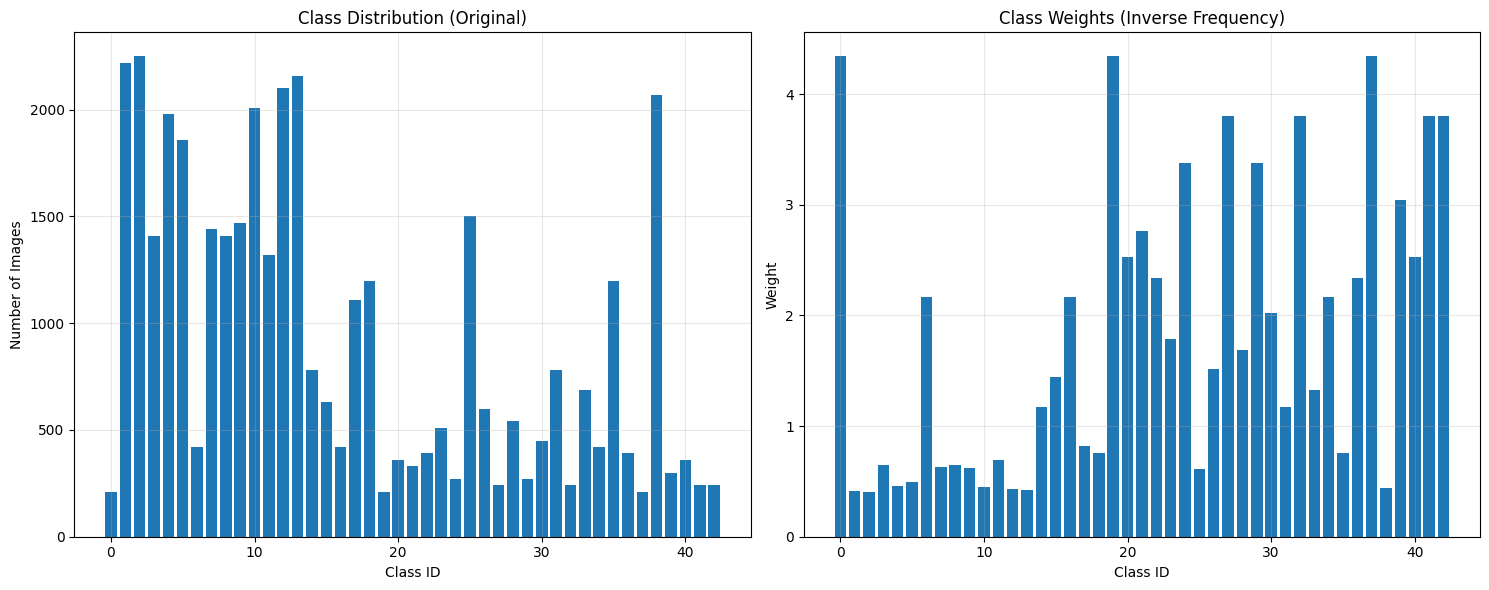

In [13]:
#ANALYZE distrib and classweights

print("ANALYZING DISTRIBUTION AND CALCULATING CLASS WEIGHTS: ")
df, original_counts = dataset.analyze_class_distribution(labels)

class_weights = dataset.calculate_class_weights(labels)

In [15]:
# REPROCESS DATA
def preprocess_data(images, labels, num_classes):
    #SPLITS
    X_train, X_temp, y_train, y_temp = train_test_split(
        images, labels, test_size=0.3, random_state=42, stratify=labels  # 70% train 30% temp
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.6667, random_state=42, stratify=y_temp  # 10% val 20% test
    )
    
    #normalize
    def preprocess_input_resnet(x):
        x = x.astype('float32')
        x = tf.keras.applications.resnet50.preprocess_input(x)
        return x
    
    X_train = preprocess_input_resnet(X_train)
    X_val = preprocess_input_resnet(X_val)
    X_test = preprocess_input_resnet(X_test)
    
    #Convert labels to categoricals
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
    y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)
    
    return X_train, y_train_cat, X_val, y_val_cat, X_test, y_test_cat

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(
    images, labels, dataset.num_classes
)

print(f"Dataset split (using class weights):")
print(f"Train: {X_train.shape[0]:,} images")
print(f"Val: {X_val.shape[0]:,} images") 
print(f"Test: {X_test.shape[0]:,} images")

def create_gtsrb_model():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(32, 32, 3)
    )
    
    #freeze
    base_model.trainable = False
    
    #build model
    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(43, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

Dataset split (using class weights):
Train: 27,446 images
Val: 3,920 images
Test: 7,843 images


In [17]:
print("Creating GTSRB model: ")
gtsrb_model, base_model = create_gtsrb_model()

Creating GTSRB model: 


In [19]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='reflect'
)

print("TRAINING ON GTSRB WITH CLASS WEIGHTS: ")

# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_gtsrb_model.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7
)

# PHASE 1A:Frozen backbone w/ class weights
print("Phase 1A: Training with frozen backbone + class weights...")
history1 = gtsrb_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=25,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

TRAINING ON GTSRB WITH CLASS WEIGHTS: 
Phase 1A: Training with frozen backbone + class weights...
Epoch 1/25
857/857 [==============================] - 63s 70ms/step - loss: 2.0746 - accuracy: 0.3595 - val_loss: 1.5038 - val_accuracy: 0.5092 - lr: 0.0010
Epoch 2/25
857/857 [==============================] - 66s 77ms/step - loss: 1.4721 - accuracy: 0.4787 - val_loss: 1.2301 - val_accuracy: 0.5944 - lr: 0.0010
Epoch 3/25
857/857 [==============================] - 63s 73ms/step - loss: 1.2924 - accuracy: 0.5199 - val_loss: 1.1946 - val_accuracy: 0.5888 - lr: 0.0010
Epoch 4/25
857/857 [==============================] - 64s 75ms/step - loss: 1.1863 - accuracy: 0.5548 - val_loss: 1.0809 - val_accuracy: 0.6298 - lr: 0.0010
Epoch 5/25
857/857 [==============================] - 63s 74ms/step - loss: 1.0833 - accuracy: 0.5789 - val_loss: 1.1068 - val_accuracy: 0.6245 - lr: 0.0010
Epoch 6/25
857/857 [==============================] - 64s 74ms/step - loss: 1.0402 - accuracy: 0.5981 - val_loss: 0.9

In [21]:
# PHASE 1B: Fine-tuning w/ class weights
print("Phase 1B: Fine-tuning with class weights...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

gtsrb_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = gtsrb_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=20,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

Phase 1B: Fine-tuning with class weights...
Epoch 1/20
857/857 [==============================] - 694s 805ms/step - loss: 0.9029 - accuracy: 0.6571 - val_loss: 0.7227 - val_accuracy: 0.7446 - lr: 1.0000e-04
Epoch 2/20
857/857 [==============================] - 676s 788ms/step - loss: 0.7143 - accuracy: 0.7012 - val_loss: 0.7295 - val_accuracy: 0.7457 - lr: 1.0000e-04
Epoch 3/20
857/857 [==============================] - 675s 787ms/step - loss: 0.6348 - accuracy: 0.7277 - val_loss: 0.6061 - val_accuracy: 0.7898 - lr: 1.0000e-04
Epoch 4/20
857/857 [==============================] - 677s 790ms/step - loss: 0.5593 - accuracy: 0.7511 - val_loss: 0.6154 - val_accuracy: 0.7885 - lr: 1.0000e-04
Epoch 5/20
857/857 [==============================] - 689s 804ms/step - loss: 0.5371 - accuracy: 0.7573 - val_loss: 0.6223 - val_accuracy: 0.7793 - lr: 1.0000e-04
Epoch 6/20
857/857 [==============================] - 706s 823ms/step - loss: 0.5128 - accuracy: 0.7722 - val_loss: 0.7956 - val_accuracy: 0.

In [25]:
#SAVE MODEL
gtsrb_model.save('resnet50_gtsrb_pretrained.h5')
print("MODEL: resnet50_gtsrb_pretrained.h5")

MODEL: resnet50_gtsrb_pretrained.h5


GTSRB Test Accuracy: 0.8831 (88.31%)


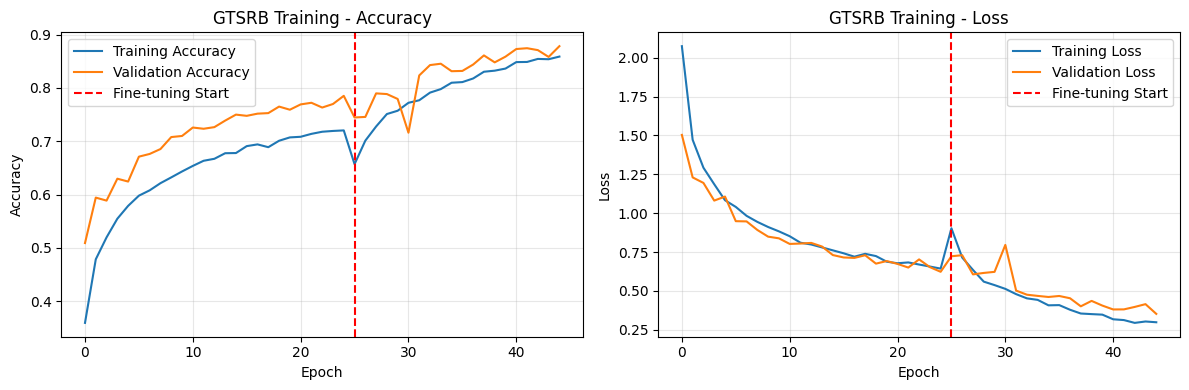

In [27]:
#EVAL

gtsrb_model.load_weights('best_gtsrb_model.h5')
test_loss, test_accuracy = gtsrb_model.evaluate(X_test, y_test, verbose=0)
print(f"GTSRB Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

def plot_training_history(history1, history2, title):
    plt.figure(figsize=(12, 4))
    
    if history2:
        acc = history1.history['accuracy'] + history2.history['accuracy']
        val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
        loss = history1.history['loss'] + history2.history['loss']
        val_loss = history1.history['val_loss'] + history2.history['val_loss']
    else:
        acc = history1.history['accuracy']
        val_acc = history1.history['val_accuracy']
        loss = history1.history['loss']
        val_loss = history1.history['val_loss']
    
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    if history2:
        plt.axvline(x=len(history1.history['accuracy']), color='r', linestyle='--', label='Fine-tuning Start')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    if history2:
        plt.axvline(x=len(history1.history['loss']), color='r', linestyle='--', label='Fine-tuning Start')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history1, history2, "GTSRB Training")